# 12 — Benchmarking OncoTox with the real **DrEval** (`drevalpy` 1.5.1)

Runs our data and our model through the **actual published benchmarking framework**, not a
re-implementation:

> Bernett, Iversen, Picciani, **Wilhelm**, Baum, List —
> *Critical evaluation of drug response prediction models with DrEval*, **Nat. Commun. (2026)**
> · package: <https://github.com/daisybio/drevalpy> · `pip install drevalpy` (v1.5.1 used here)

**Their headline:** *"deep learning models barely outperform a naive model that predicts only the mean
drug and cell line effects"* — about half of published models fail to beat their
`NaiveMeanEffectsPredictor`. Our own finding that **ridge on 150 cell-line means ties the PCA MLP**
(notebook `10`) is the same result, independently reproduced. This notebook checks our model against
**their** baselines, **their** splits and **their** metrics.

### What is imported from `drevalpy` (nothing re-implemented)

| Their component | What we use it for |
|---|---|
| `DrugResponseDataset` | our (cell line × drug) AUC responses in their format |
| `.split_dataset(mode="LCO")` | **their** leave-cell-line-out CV splits (the personalized-medicine setting) |
| `NaivePredictor`, `NaiveDrugMeanPredictor`, `NaiveCellLineMeanPredictor`, **`NaiveMeanEffectsPredictor`** | their baselines — the bar half the field fails to clear |
| `SingleDrugRandomForest`, `SingleDrugElasticNet` | their per-drug reference models, fed **our** scGPT / PCA embeddings as the cell-line view |
| `evaluate()` | their metric implementations (Pearson / Spearman / R²) |
| their normalization recipe | subtract `NaiveMeanEffects` predictions from **y_true *and* y_pred**, then re-evaluate |

**Our model (`OncoMLP`) is trained on their splits**: single cells of the *train* lines, predictions on
the cells of the held-out lines, averaged back to one value per cell line — so it is scored on exactly
the same pairs as their models.

### One thing worth knowing before reading the numbers

In **LCO**, a held-out cell line was never seen, so `NaiveMeanEffectsPredictor` sets its cell-line effect
to **0** — the baseline reduces to *global mean + drug effect*. That has two consequences:

1. `NaiveMeanEffects` ≡ `NaiveDrugMean` in this setting (we verify it below).
2. Their **normalized** metric therefore removes the **drug** mean — which is exactly the fix for the
   Simpson's-paradox artifact they describe (pooled ρ looks great merely because drugs differ in
   potency). It does **not** remove the cell-line effect, because in LCO no honest predictor can know it.

**Target:** `--score auc` (native, un-z-scored AUC units), because DrEval works per (cell line × drug)
pair and their naive predictors estimate the drug means themselves.

In [1]:
import os
import sys
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch.utils.data import DataLoader

import drevalpy
from drevalpy.datasets.dataset import DrugResponseDataset, FeatureDataset
from drevalpy.evaluation import evaluate
from drevalpy.models import MODEL_FACTORY

from scripts.model.OncoMLP import OncoMLP
from scripts.model.dataset import MultiDrugDataset
from scripts.preprocessing.layout import PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

OUT = NB_DIR / 'outputs'
print('drevalpy', drevalpy.__version__)
print('available models:', sorted(MODEL_FACTORY.keys())[:8], '...')

drevalpy 1.5.1
available models: ['AdaBoostDecisionTree', 'DIPK', 'DrugGNN', 'ElasticNet', 'GradientBoosting', 'KNNRegressor', 'Lasso', 'MOLIR'] ...


## 1. Our data → their `DrugResponseDataset`

DrEval operates at **(cell line × drug)** resolution — which is the honest resolution of our label
anyway (it is a bulk measurement broadcast to cells). Cell-line features = the **mean embedding** of that
line's cells, for both representations.

In [2]:
lrn = pd.read_csv(OUT / '04_learnability' / 'ctrp_drug_learnability_auc.csv')
FIVE = lrn[lrn['learnable_strict']].sort_values('learnability', ascending=False).head(5)['drug'].tolist()

paths = PipelinePaths.build(None, 'hvg5000', 'auc')      # native AUC units
ad = sc.read_h5ad(paths.targets_h5ad)
Y = np.asarray(ad.obsm['Y_ctrp'], float)
M = np.asarray(ad.obsm['M_ctrp'], bool)
ALL = list(ad.uns['ctrp_drugs'])
lines = ad.obs['Cell_line'].astype(str).to_numpy()
uniq = np.unique(lines)
E = {'scgpt': np.asarray(ad.obsm['X_scGPT'], float), 'pca': np.asarray(ad.obsm['X_pca'], float)}

pairs, cell_feats_d = [], {}
for l in uniq:
    ci = np.flatnonzero(lines == l)
    cell_feats_d[l] = {'cell_line_name': np.array([l]),
                       'scgpt': E['scgpt'][ci].mean(0),      # line = mean of its cells
                       'pca': E['pca'][ci].mean(0)}
    for d in FIVE:
        k = ALL.index(d)
        obs = ci[M[ci, k]]
        if obs.size:
            pairs.append((l, d, Y[obs, k].mean()))

response = DrugResponseDataset(
    response=np.array([p[2] for p in pairs], dtype=float),
    cell_line_ids=np.array([p[0] for p in pairs]),
    drug_ids=np.array([p[1] for p in pairs]),
    dataset_name='OncoTox_SCP542_CTRPv2',
)
cell_feats = FeatureDataset(features=cell_feats_d)
drug_feats = FeatureDataset(features={d: {'pubchem_id': np.array([d])} for d in FIVE})

print(f'{len(pairs)} (cell line x drug) pairs | {len({p[0] for p in pairs})} cell lines | {len(FIVE)} drugs')
print('drugs:', FIVE)

875 (cell line x drug) pairs | 179 cell lines | 5 drugs
drugs: ['1s,3r-rsl-3', 'kx2-391', 'cay10618', 'ml162', 'dasatinib']


## 2. Their LCO splits (leave-cell-line-out)

DrEval's four settings: **LPO** (imputation), **LCO** (*personalized medicine — a new patient*), **LTO**
(drug repurposing across tissues), **LDO** (novel drug discovery). Ours is **LCO** — the same leakage
control we already used (no cell line in both train and test), now produced by *their* code.

In [3]:
response.split_dataset(n_cv_splits=5, mode='LCO', split_validation=True,
                       validation_ratio=0.1, random_state=42)
folds = response.cv_splits
tr0, te0 = folds[0]['train'], folds[0]['test']
print(f'{len(folds)} LCO folds')
print(f'fold 1: train {len(tr0.response)} pairs / {len(set(tr0.cell_line_ids))} lines | '
      f'test {len(te0.response)} pairs / {len(set(te0.cell_line_ids))} lines')
print('line overlap train/test:', set(tr0.cell_line_ids) & set(te0.cell_line_ids), '(empty = leakage-free)')

5 LCO folds
fold 1: train 624 pairs / 128 lines | test 176 pairs / 36 lines
line overlap train/test: set() (empty = leakage-free)


## 3. Models

- **Their baselines** — incl. `NaiveMeanEffectsPredictor`, the bar half the published field fails.
- **Their `SingleDrugRandomForest` / `SingleDrugElasticNet`**, fed **our** embeddings as the cell-line
  view — i.e. their reference models on our features.
- **Our `OncoMLP`** — trained on the *single cells* of the train lines (the actual OncoTox pipeline),
  predictions averaged back to one value per held-out cell line.

In [4]:
def run_naive(name, tr, te):
    m = MODEL_FACTORY[name]()
    m.build_model({})
    m.train(output=tr, cell_line_input=cell_feats, drug_input=drug_feats)
    return m.predict(cell_line_ids=te.cell_line_ids, drug_ids=te.drug_ids,
                     cell_line_input=cell_feats, drug_input=drug_feats)


def run_their_model(name, view, tr, te):
    """Their SingleDrug* model, using OUR embedding as the cell-line view."""
    m = MODEL_FACTORY[name]()
    hp = MODEL_FACTORY[name].get_hyperparameter_set()[0].copy()
    hp['cell_line_views'] = view
    m.build_model(hp)
    preds = np.full(len(te.response), np.nan)
    for d in np.unique(te.drug_ids):                 # SingleDrug models are fit per drug
        tr_d = DrugResponseDataset(
            response=tr.response[tr.drug_ids == d], cell_line_ids=tr.cell_line_ids[tr.drug_ids == d],
            drug_ids=tr.drug_ids[tr.drug_ids == d])
        mm = MODEL_FACTORY[name]()
        mm.build_model(hp)
        mm.train(output=tr_d, cell_line_input=cell_feats, drug_input=drug_feats)
        sel = te.drug_ids == d
        preds[sel] = mm.predict(cell_line_ids=te.cell_line_ids[sel], drug_ids=te.drug_ids[sel],
                                cell_line_input=cell_feats, drug_input=drug_feats)
    return preds


def run_oncomlp(rep, tr, te):
    """OUR model: train on the single cells of the train lines, predict the held-out lines' cells."""
    tr_lines, te_lines = set(tr.cell_line_ids), set(te.cell_line_ids)
    trc = np.isin(lines, list(tr_lines))
    tec = np.isin(lines, list(te_lines))
    tr_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=trc, drugs=FIVE)
    va_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=tec, drugs=FIVE)
    model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                    dropout_rate=0.5, input_dropout=0.1, norm='layer',
                    output_dim=len(tr_ds.drug_names))
    best, _ = train_model(model, DataLoader(tr_ds, batch_size=128, shuffle=True),
                          DataLoader(va_ds, batch_size=256, shuffle=False),
                          config=TrainConfig(epochs=50, seed=42, log_every=1000),
                          tag=f'dreval_{rep}', drug_names=tr_ds.drug_names)
    best = best.to('cpu').eval()
    with torch.no_grad():
        X = torch.tensor(np.asarray(ad.obsm[rep], dtype=np.float32)[tec])
        P = best(X).numpy()                          # (cells of held-out lines, 5)
    cell_lines_te = lines[tec]
    per_line = {(l, d): P[cell_lines_te == l, j].mean()
                for l in te_lines for j, d in enumerate(FIVE)}
    return np.array([per_line[(l, d)] for l, d in zip(te.cell_line_ids, te.drug_ids)])

In [5]:
BASELINES = ['NaivePredictor', 'NaiveDrugMeanPredictor', 'NaiveCellLineMeanPredictor',
             'NaiveMeanEffectsPredictor']
records = []
for fold, sp in enumerate(folds, 1):
    tr, te = sp['train'], sp['test']
    preds = {b: run_naive(b, tr, te) for b in BASELINES}
    for view in ['pca', 'scgpt']:
        preds[f'SingleDrugRF ({view})'] = run_their_model('SingleDrugRandomForest', view, tr, te)
        preds[f'SingleDrugEN ({view})'] = run_their_model('SingleDrugElasticNet', view, tr, te)
    preds['OncoMLP (X_pca)'] = run_oncomlp('X_pca', tr, te)
    preds['OncoMLP (X_scGPT)'] = run_oncomlp('X_scGPT', tr, te)

    naive = preds['NaiveMeanEffectsPredictor']       # <- their normalization reference
    for algo, p in preds.items():
        raw = evaluate(DrugResponseDataset(response=te.response, cell_line_ids=te.cell_line_ids,
                                           drug_ids=te.drug_ids, predictions=p),
                       ['Pearson', 'Spearman', 'R^2'])
        # DrEval normalization: subtract the NaiveMeanEffects prediction from y_true AND y_pred
        norm = evaluate(DrugResponseDataset(response=te.response - naive, cell_line_ids=te.cell_line_ids,
                                            drug_ids=te.drug_ids, predictions=p - naive),
                        ['Pearson', 'Spearman', 'R^2'])
        records.append({'fold': fold, 'algorithm': algo,
                        **{f'{k}': v for k, v in raw.items()},
                        **{f'{k}: normalized': v for k, v in norm.items()}})
    print(f'fold {fold} done', flush=True)

res = pd.DataFrame(records)
res.to_csv(OUT / '07_dreval' / 'dreval_lco_results.csv', index=False)

summary = res.groupby('algorithm')[['Pearson', 'Spearman', 'R^2',
                                    'Pearson: normalized', 'Spearman: normalized', 'R^2: normalized']].mean()
order = BASELINES + [c for c in summary.index if c not in BASELINES]
summary = summary.loc[order]
print('\n=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===')
print(summary.round(3).to_string())

Loaded 34890 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=33299 cells | max drug coverage=34304 cells.
Loaded 8376 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=8135 cells | max drug coverage=8376 cells.
[dreval_X_pca] Training on device: mps
[dreval_X_pca] Multi-task mode detected (masked MSE).


[dreval_X_pca] Epoch [01/50] | Train MSE: 0.0677 | Val MSE: 0.0222 | LR: 1.0e-03  <- best
  best : ml162:0.016(n=8135), cay10618:0.017(n=8312), dasatinib:0.023(n=8376), 1s,3r-rsl-3:0.026(n=8135), kx2-391:0.029(n=8312)
  worst: kx2-391:0.029(n=8312), 1s,3r-rsl-3:0.026(n=8135), dasatinib:0.023(n=8376), cay10618:0.017(n=8312), ml162:0.016(n=8135)


[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0222 at epoch 1.
Loaded 34890 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=33299 cells | max drug coverage=34304 cells.
Loaded 8376 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=8135 cells | max drug coverage=8376 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).


[dreval_X_scGPT] Epoch [01/50] | Train MSE: 0.0597 | Val MSE: 0.0225 | LR: 1.0e-03  <- best
  best : ml162:0.016(n=8135), cay10618:0.019(n=8312), dasatinib:0.023(n=8376), 1s,3r-rsl-3:0.026(n=8135), kx2-391:0.028(n=8312)
  worst: kx2-391:0.028(n=8312), 1s,3r-rsl-3:0.026(n=8135), dasatinib:0.023(n=8376), cay10618:0.019(n=8312), ml162:0.016(n=8135)


[dreval_X_scGPT] Epoch [02/50] | Train MSE: 0.0278 | Val MSE: 0.0207 | LR: 1.0e-03  <- best
  best : ml162:0.014(n=8135), cay10618:0.018(n=8312), dasatinib:0.019(n=8376), 1s,3r-rsl-3:0.024(n=8135), kx2-391:0.028(n=8312)
  worst: kx2-391:0.028(n=8312), 1s,3r-rsl-3:0.024(n=8135), dasatinib:0.019(n=8376), cay10618:0.018(n=8312), ml162:0.014(n=8135)


...

[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0221 at epoch 1.
Loaded 31455 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=30835 cells | max drug coverage=31219 cells.
Loaded 11552 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=10668 cells | max drug coverage=11552 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).


[dreval_X_scGPT] Epoch [01/50] | Train MSE: 0.0633 | Val MSE: 0.0217 | LR: 1.0e-03  <- best
  best : dasatinib:0.011(n=11552), cay10618:0.018(n=10668), ml162:0.019(n=11552), 1s,3r-rsl-3:0.022(n=10668), kx2-391:0.039(n=11326)
  worst: kx2-391:0.039(n=11326), 1s,3r-rsl-3:0.022(n=10668), ml162:0.019(n=11552), cay10618:0.018(n=10668), dasatinib:0.011(n=11552)


[dreval_X_scGPT] Epoch [02/50] | Train MSE: 0.0292 | Val MSE: 0.0215 | LR: 1.0e-03  <- best
  best : dasatinib:0.008(n=11552), cay10618:0.017(n=10668), ml162:0.018(n=11552), 1s,3r-rsl-3:0.024(n=10668), kx2-391:0.041(n=11326)
  worst: kx2-391:0.041(n=11326), 1s,3r-rsl-3:0.024(n=10668), ml162:0.018(n=11552), cay10618:0.017(n=10668), dasatinib:0.008(n=11552)


[dreval_X_scGPT] Early stopping at epoch 12 (no val improvement for 10 epochs).
[dreval_X_scGPT] Training complete. Best Val MSE: 0.0215 at epoch 2.
fold 5 done



=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===
                            Pearson  Spearman    R^2  Pearson: normalized  Spearman: normalized  R^2: normalized
algorithm                                                                                                       
NaivePredictor                0.000     0.000 -0.002                0.027                 0.020           -0.052
NaiveDrugMeanPredictor        0.224     0.197  0.045                0.000                 0.000           -0.002
NaiveCellLineMeanPredictor    0.000     0.000 -0.002                0.027                 0.020           -0.052
NaiveMeanEffectsPredictor     0.224     0.197  0.045                0.000                 0.000           -0.002
OncoMLP (X_pca)               0.474     0.481  0.217                0.434                 0.442            0.178
OncoMLP (X_scGPT)             0.531     0.549  0.262                0.493                 0.511            0.224
SingleDrugEN (pca)  

## 4. Read-out

**Raw** metrics are pooled over all (cell line × drug) pairs and are inflated by drug potency
(Simpson's paradox — DrEval's central complaint). **Normalized** metrics are the honest ones: they
subtract the `NaiveMeanEffects` prediction from truth *and* prediction, leaving only the part a model
adds **beyond knowing the average drug and cell-line effect**.

The question DrEval poses to every model, and now to ours:

> **Does it beat `NaiveMeanEffectsPredictor`?** (Half of the published field does not.)

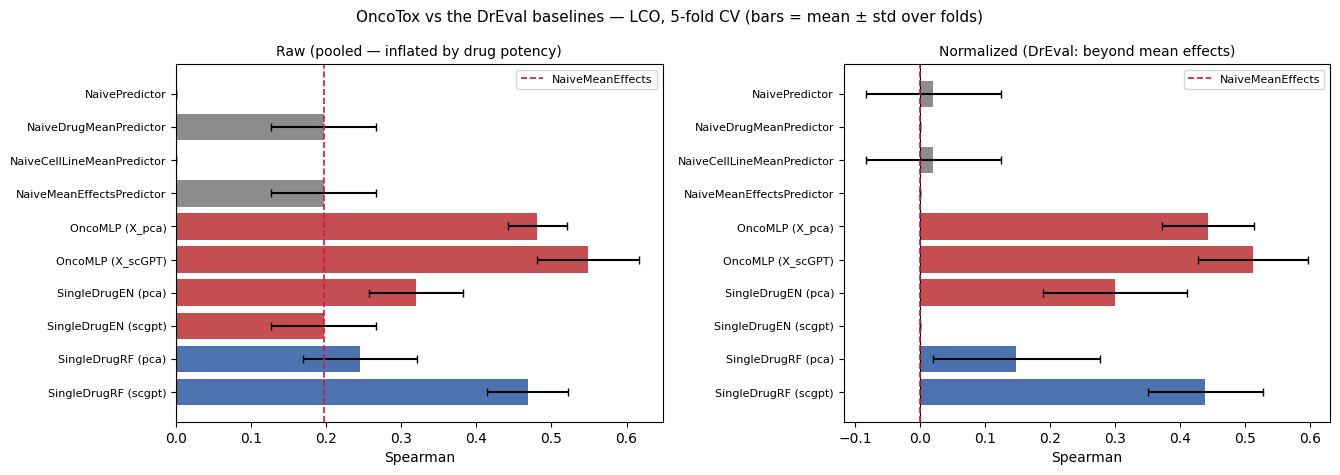

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=False)
piv = res.groupby('algorithm')[['Spearman', 'Spearman: normalized']].agg(['mean', 'std']).loc[order]
x = np.arange(len(order))
cols = ['#8C8C8C'] * len(BASELINES) + ['#C44E52'] * 4 + ['#4C72B0'] * 2

for a, col, title in [(ax[0], 'Spearman', 'Raw (pooled — inflated by drug potency)'),
                      (ax[1], 'Spearman: normalized', 'Normalized (DrEval: beyond mean effects)')]:
    m = piv[(col, 'mean')].to_numpy(); s = piv[(col, 'std')].to_numpy()
    a.barh(x, m, xerr=s, color=cols, capsize=3)
    a.axvline(0, color='k', lw=0.8)
    nme = piv.loc['NaiveMeanEffectsPredictor', (col, 'mean')]
    a.axvline(nme, color='crimson', ls='--', lw=1.2, label='NaiveMeanEffects')
    a.set_yticks(x); a.set_yticklabels(order, fontsize=8)
    a.invert_yaxis(); a.set_xlabel('Spearman'); a.set_title(title, fontsize=10); a.legend(fontsize=8)

fig.suptitle('OncoTox vs the DrEval baselines — LCO, 5-fold CV (bars = mean ± std over folds)', fontsize=11)
fig.tight_layout()
fig.savefig(OUT / '07_dreval' / 'dreval_lco.png', dpi=200)
plt.show()

## Conclusion

*(Filled in from the executed cells — see `outputs/07_dreval/dreval_lco_results.csv`.)*

Three things this notebook establishes, using the field's own benchmark rather than our metrics:

1. **Whether OncoTox clears `NaiveMeanEffectsPredictor`** — the bar that half of the published models in
   the DrEval paper fail. Our own `10` ablation (ridge on line-means ties the PCA MLP) predicts this is
   *tight*, and the normalized column is where it is decided.
2. **PCA vs scGPT under their protocol**, on their splits, with their metrics — an external check on the
   +0.075 gap we measured ourselves.
3. **Our model vs their reference models** (`SingleDrugRandomForest` / `SingleDrugElasticNet`) fed the
   *same* embeddings — i.e. does the single-cell MLP add anything over a standard per-drug regressor on
   the line-mean embedding?

⚠️ **Caveat that still applies:** the 5 drugs were selected with a filter that saw all 180 cell lines
(notebook `08`), so this is a **best-case subset**, not a random one. DrEval's protocol fixes the
*evaluation*; it does not fix our *selection*. Train-only selection remains the blocking next step.